## Business Objective

The objective of this analysis is to understand and predict ad exposure count
for users on a media platform, with the goal of identifying key drivers of
ad exposure and generating insights that can support media planning,
campaign optimization, and audience targeting decisions.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
# data loading 
raw_df = pd.read_csv("Media_analytics_synthetic_50k.csv")
raw_df.head()

,event_id,user_id,age_group,gender,device_type,os,content_type,content_genre,watch_duration_minutes,session_start_hour,ad_exposure_count,ad_skipped,subscription_type,network_type,buffering_events,rating_given,timestamp
0,1,1785,25-34,Female,Mobile,Android,News,Action,13.33,16,4,0,Ad-supported,4G,1,3.0,23-03-2025 01:39
1,2,1359,55+,Female,Laptop,Windows,News,Sports,11.84,9,2,0,Free,WiFi,0,3.0,24-06-2025 03:36
2,3,3214,45-54,Male,Mobile,iOS,News,Comedy,24.25,21,4,0,Free,4G,0,3.0,05-02-2025 23:36
3,4,17101,45-54,Female,Tablet,Windows,Movie,Comedy,31.93,8,1,0,Free,WiFi,1,4.0,15-03-2025 12:50
4,5,8184,45-54,Male,Laptop,Android,Kids,Drama,23.09,19,3,0,Ad-supported,4G,0,5.0,28-01-2025 09:59


In [3]:
#information of the raw data 
raw_df.info()
print("="*60)
print("Interpretation:")
print("-"*60)
print("There are only nulls in rating_given feature")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_id                50000 non-null  int64  
 1   user_id                 50000 non-null  int64  
 2   age_group               50000 non-null  object 
 3   gender                  50000 non-null  object 
 4   device_type             50000 non-null  object 
 5   os                      50000 non-null  object 
 6   content_type            50000 non-null  object 
 7   content_genre           50000 non-null  object 
 8   watch_duration_minutes  50000 non-null  float64
 9   session_start_hour      50000 non-null  int64  
 10  ad_exposure_count       50000 non-null  int64  
 11  ad_skipped              50000 non-null  int64  
 12  subscription_type       50000 non-null  object 
 13  network_type            50000 non-null  object 
 14  buffering_events        50000 non-null

In [4]:
# describe the data 
raw_df.describe()

,event_id,user_id,watch_duration_minutes,session_start_hour,ad_exposure_count,ad_skipped,buffering_events,rating_given
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49053.000000
mean,25000.500000,9998.290000,29.963837,13.085220,2.069560,0.249840,0.504660,3.254256
std,14433.901067,5787.473491,29.796990,6.497775,1.640529,0.432925,0.710372,1.173998
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,12500.750000,4995.000000,8.580000,7.000000,1.000000,0.000000,0.000000,3.000000
50%,25000.500000,10026.000000,20.930000,13.000000,2.000000,0.000000,0.000000,3.000000
75%,37500.250000,15006.000000,41.590000,19.000000,3.000000,0.000000,1.000000,4.000000
max,50000.000000,19999.000000,327.430000,23.000000,13.000000,1.000000,5.000000,5.000000


### Interpretation
1. Average watch duration is roughly 30 minutes with stadard deviation of 30 minutest
2. Only 25% people watch duration is more than 40 min's
3. Average session_start_hour is nearly 1 pm
4. Every person encountered on an average 2 ads
5. Around 75% people encountered atmost 3 ads
6. On an average Rating is 3 - 3.25

In [5]:
# Checking how many unique users 
unique_users = raw_df['user_id'].nunique()
print(f"There is data of only {unique_users} users")

There is data of only 18345 users


In [6]:
# check whethere is there any inconsistency in data per user
raw_df[raw_df['user_id']==3164]

,event_id,user_id,age_group,gender,device_type,os,content_type,content_genre,watch_duration_minutes,session_start_hour,ad_exposure_count,ad_skipped,subscription_type,network_type,buffering_events,rating_given,timestamp
376,377,3164,18-24,Female,Laptop,Android,TV Show,Documentary,70.53,8,3,0,Free,WiFi,1,4.0,09-02-2025 23:19
8411,8412,3164,25-34,Female,Laptop,Windows,Live Sports,Drama,46.72,23,1,1,Ad-supported,4G,0,1.0,05-06-2025 20:47
9539,9540,3164,18-24,Female,Mobile,Windows,Movie,Documentary,23.97,21,3,1,Ad-supported,WiFi,0,1.0,28-06-2025 17:38
13633,13634,3164,45-54,Male,Tablet,macOS,Movie,Comedy,40.03,21,5,0,Ad-supported,WiFi,1,3.0,16-05-2025 19:28
47505,47506,3164,25-34,Female,Laptop,Windows,TV Show,Romance,94.53,3,2,0,Free,5G,0,2.0,15-02-2025 04:32


## Data Quality & Consistency Checks

In media measurement, user-level consistency is critical for accurate
audience analysis. Inconsistent demographic attributes for the same user
can bias exposure estimates.
### Solution: 
- for now just considering the each each row as unique user

In [7]:
# droping the inconsitent data and proceeding with this data
raw_df.drop_duplicates('user_id')

,event_id,user_id,age_group,gender,device_type,os,content_type,content_genre,watch_duration_minutes,session_start_hour,ad_exposure_count,ad_skipped,subscription_type,network_type,buffering_events,rating_given,timestamp
0,1,1785,25-34,Female,Mobile,Android,News,Action,13.33,16,4,0,Ad-supported,4G,1,3.0,23-03-2025 01:39
1,2,1359,55+,Female,Laptop,Windows,News,Sports,11.84,9,2,0,Free,WiFi,0,3.0,24-06-2025 03:36
2,3,3214,45-54,Male,Mobile,iOS,News,Comedy,24.25,21,4,0,Free,4G,0,3.0,05-02-2025 23:36
3,4,17101,45-54,Female,Tablet,Windows,Movie,Comedy,31.93,8,1,0,Free,WiFi,1,4.0,15-03-2025 12:50
4,5,8184,45-54,Male,Laptop,Android,Kids,Drama,23.09,19,3,0,Ad-supported,4G,0,5.0,28-01-2025 09:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49922,49923,19653,18-24,Male,Tablet,Linux,Live Sports,Action,60.33,7,1,0,Premium,WiFi,0,2.0,11-01-2025 07:39
49927,49928,4161,25-34,Male,Smart TV,Linux,News,Documentary,3.37,8,3,1,Ad-supported,Broadband,0,2.0,11-01-2025 10:22
49942,49943,16492,55+,Female,Tablet,Windows,Kids,Sports,1.27,18,1,1,Premium,WiFi,1,3.0,07-03-2025 03:25
49944,49945,11675,18-24,Female,Smart TV,iOS,News,Thriller,29.32,9,1,0,Free,4G,2,3.0,05-02-2025 03:42


In [8]:
raw_df.drop(columns=['user_id','event_id'],inplace=True)
raw_df

,age_group,gender,device_type,os,content_type,content_genre,watch_duration_minutes,session_start_hour,ad_exposure_count,ad_skipped,subscription_type,network_type,buffering_events,rating_given,timestamp
0,25-34,Female,Mobile,Android,News,Action,13.33,16,4,0,Ad-supported,4G,1,3.0,23-03-2025 01:39
1,55+,Female,Laptop,Windows,News,Sports,11.84,9,2,0,Free,WiFi,0,3.0,24-06-2025 03:36
2,45-54,Male,Mobile,iOS,News,Comedy,24.25,21,4,0,Free,4G,0,3.0,05-02-2025 23:36
3,45-54,Female,Tablet,Windows,Movie,Comedy,31.93,8,1,0,Free,WiFi,1,4.0,15-03-2025 12:50
4,45-54,Male,Laptop,Android,Kids,Drama,23.09,19,3,0,Ad-supported,4G,0,5.0,28-01-2025 09:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,25-34,Female,Tablet,iOS,News,Thriller,86.20,7,4,0,Ad-supported,5G,0,3.0,08-06-2025 15:45
49996,45-54,Female,Smart TV,iOS,TV Show,Drama,64.75,9,6,0,Ad-supported,4G,0,4.0,01-06-2025 13:51
49997,45-54,Male,Laptop,macOS,Movie,Romance,17.64,19,2,0,Ad-supported,4G,0,1.0,01-03-2025 08:36
49998,35-44,Male,Set-top Box,Linux,News,Action,15.14,20,1,1,Premium,4G,0,4.0,17-05-2025 09:54


In [9]:
# separation of features 
num_cols = raw_df.select_dtypes(include=['int64', 'float64']).columns.tolist() 
cat_cols = raw_df.select_dtypes(include=['object', 'category']).columns.tolist() 

# Exploratory Data Analysis

### Numerical Columns 
- Histograms : checking the distribution
- Boxplot : Checking the Outliers


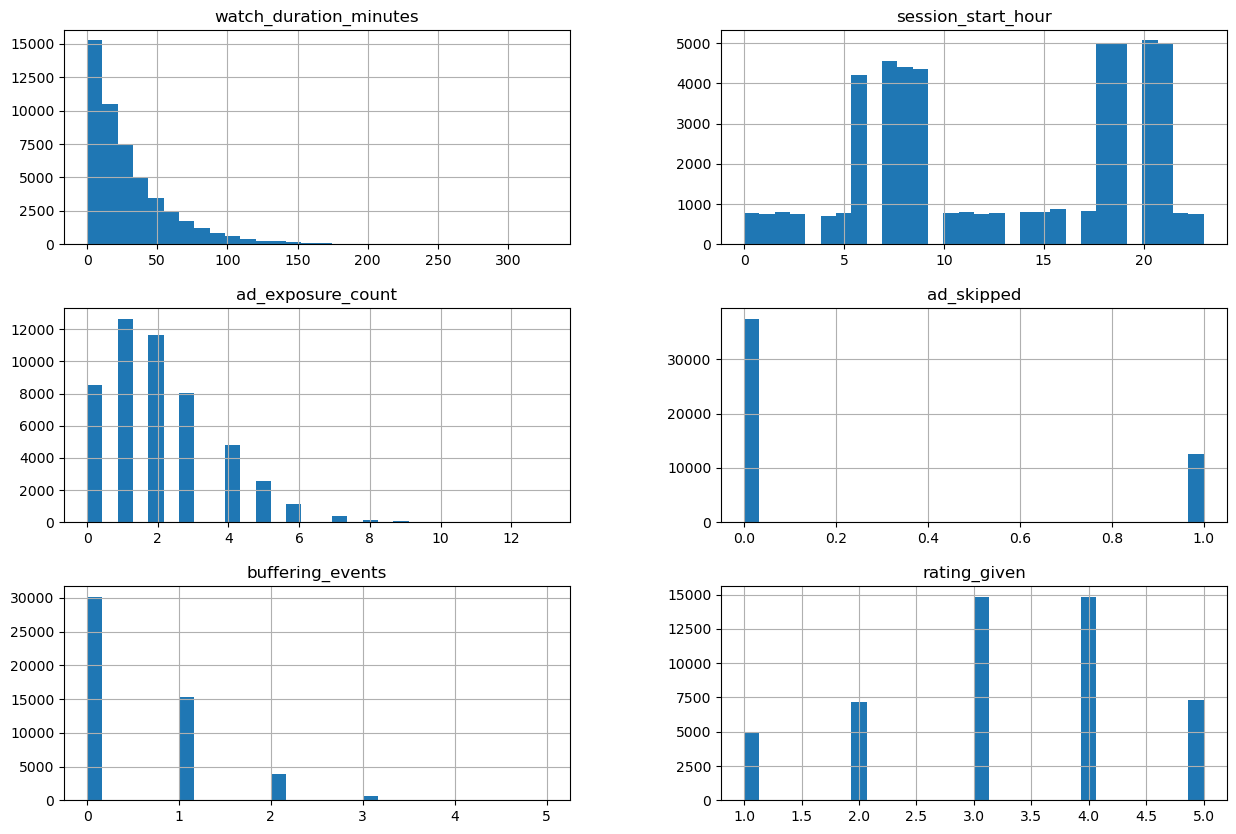

In [10]:
raw_df.hist(bins=30, figsize=(15,10))
plt.show()

**Interpretation:**  
The distribution shows that ad exposure is right-skewed, with most users
receiving a relatively low number of ads while a smaller group experiences
high exposure. This indicates uneven exposure across users and highlights
the risk of over-exposing a small segment of the audience.

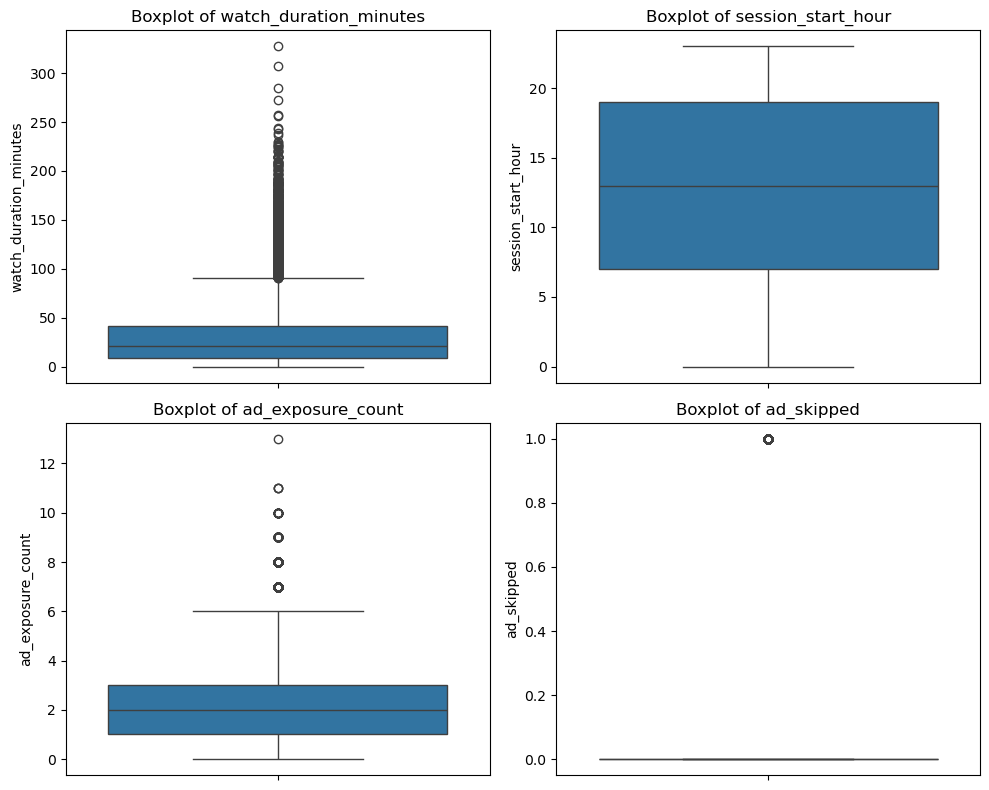

In [11]:
# ploting boxplots for each num_cols 
fig, axes = plt.subplots(2,2,figsize=(10,8))
axes = axes.flatten()
for i, ax in zip(num_cols,axes):
    sns.boxplot(raw_df[i],ax=ax)
    ax.set_title(f"Boxplot of {i}")
plt.tight_layout()
plt.show()

**Interpretation:**  
The boxplot highlights clear variation in ad exposure across groups.
Some segments show higher median exposure and wider spread, indicating
differences in both typical exposure levels and variability across users.

In [12]:
cat_cols.extend(['ad_skipped','buffering_events','rating_given'])

In [13]:
# checking for the outlier values in ad_exposure_count
print("Percentage of total ")
raw_df['ad_exposure_count'].value_counts()/18345

Percentage of total 


ad_exposure_count
1     0.690542
2     0.634069
0     0.466503
3     0.439084
4     0.260616
5     0.138294
6     0.062251
7     0.022240
8     0.007577
9     0.002944
10    0.001199
11    0.000164
13    0.000055
Name: count, dtype: float64

- **ad_exposure_count** is Going to be Target column
-  there are only 0 - 6 ad_exposure_count has significant propotion in the data
- Other categories are has negligible proportion in the data

Correlation of numerical columns with ad_exposure_count:

watch_duration_minutes    0.005638
session_start_hour        0.000275
ad_exposure_count         1.000000
ad_skipped                0.145592
buffering_events          0.000958
rating_given              0.005030
Name: ad_exposure_count, dtype: float64


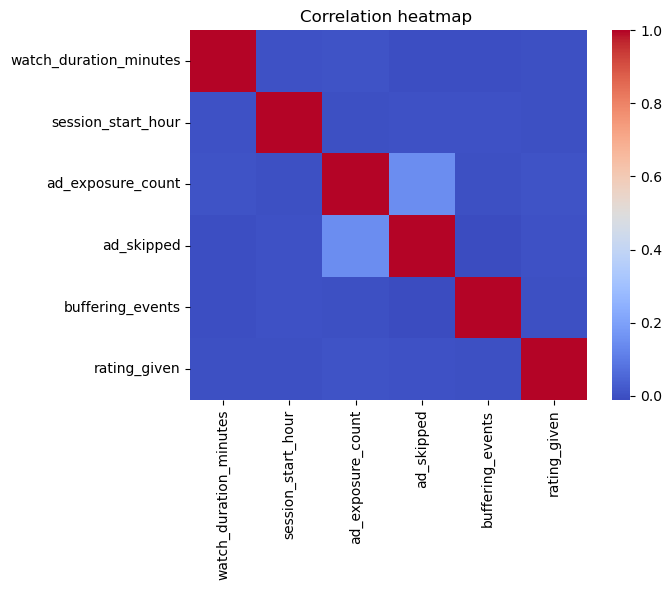

In [14]:
# correlation between the numerical feature 
corr_mat = raw_df[num_cols].corr()
print("Correlation of numerical columns with ad_exposure_count:\n")
print(corr_mat['ad_exposure_count'])

plt.title("Correlation heatmap ")
sns.heatmap(corr_mat,cmap='coolwarm')
plt.show()

### Interpretation 
- Not any one feature singnificantly corelated with the target variable 
- **ad_skipped** shows little bit correlation but it is binary feature

#### Catgorical columns 
- Exploring the Categorical columns to under stand the behaviour
- Categorical columns : ['age_group', 'gender', 'device_type', 'os', 'content_type', 'content_genre', 'subscription_type', 'network_type']

In [15]:
# convertingt the time stamp to datetime format 
raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'])
raw_df['time']=raw_df['timestamp'].dt.time
raw_df['date'] = raw_df['timestamp'].dt.date


# Weekday number (0=Monday, 6=Sunday) 
raw_df["weekday_num"] = raw_df["timestamp"].dt.weekday

# Month number (1=January, 12=December) 
raw_df["month_num"] = raw_df["timestamp"].dt.month

# Hour 
raw_df["hour"] = raw_df["timestamp"].dt.hour

def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Noon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

raw_df["time_category"] = raw_df["hour"].apply(time_of_day)

raw_df

,age_group,gender,device_type,os,content_type,content_genre,watch_duration_minutes,session_start_hour,ad_exposure_count,ad_skipped,...,network_type,buffering_events,rating_given,timestamp,time,date,weekday_num,month_num,hour,time_category
0,25-34,Female,Mobile,Android,News,Action,13.33,16,4,0,...,4G,1,3.0,2025-03-23 01:39:00,01:39:00,2025-03-23,6,3,1,Night
1,55+,Female,Laptop,Windows,News,Sports,11.84,9,2,0,...,WiFi,0,3.0,2025-06-24 03:36:00,03:36:00,2025-06-24,1,6,3,Night
2,45-54,Male,Mobile,iOS,News,Comedy,24.25,21,4,0,...,4G,0,3.0,2025-02-05 23:36:00,23:36:00,2025-02-05,2,2,23,Night
3,45-54,Female,Tablet,Windows,Movie,Comedy,31.93,8,1,0,...,WiFi,1,4.0,2025-03-15 12:50:00,12:50:00,2025-03-15,5,3,12,Noon
4,45-54,Male,Laptop,Android,Kids,Drama,23.09,19,3,0,...,4G,0,5.0,2025-01-28 09:59:00,09:59:00,2025-01-28,1,1,9,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,25-34,Female,Tablet,iOS,News,Thriller,86.20,7,4,0,...,5G,0,3.0,2025-06-08 15:45:00,15:45:00,2025-06-08,6,6,15,Noon
49996,45-54,Female,Smart TV,iOS,TV Show,Drama,64.75,9,6,0,...,4G,0,4.0,2025-06-01 13:51:00,13:51:00,2025-06-01,6,6,13,Noon
49997,45-54,Male,Laptop,macOS,Movie,Romance,17.64,19,2,0,...,4G,0,1.0,2025-03-01 08:36:00,08:36:00,2025-03-01,5,3,8,Morning
49998,35-44,Male,Set-top Box,Linux,News,Action,15.14,20,1,1,...,4G,0,4.0,2025-05-17 09:54:00,09:54:00,2025-05-17,5,5,9,Morning


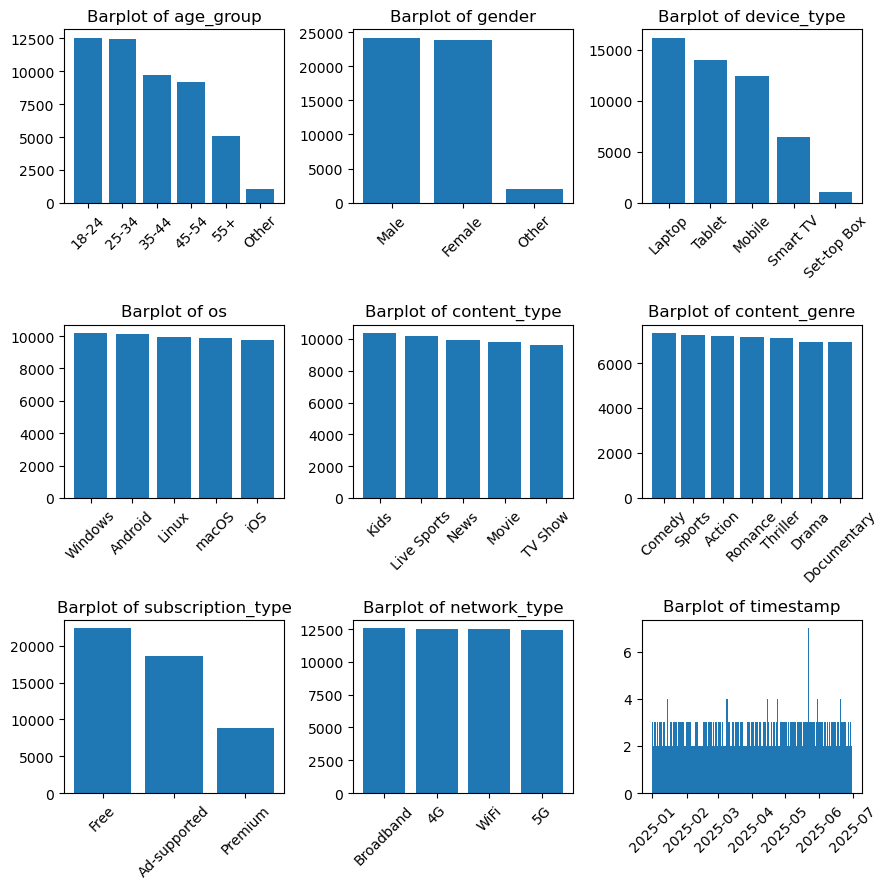

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()

for i, ax in zip(cat_cols, axes):
    counts = raw_df[i].value_counts()
    ax.bar(counts.index, counts.values)   
    ax.set_title(f"Barplot of {i}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#### Interpretation 
- Lot of users only comes form **laptop, Tablet, Mobile**
- Most of the users are from **Free and Ad-supported** tier
- Same of proportion of **network_type** and **os**
- 

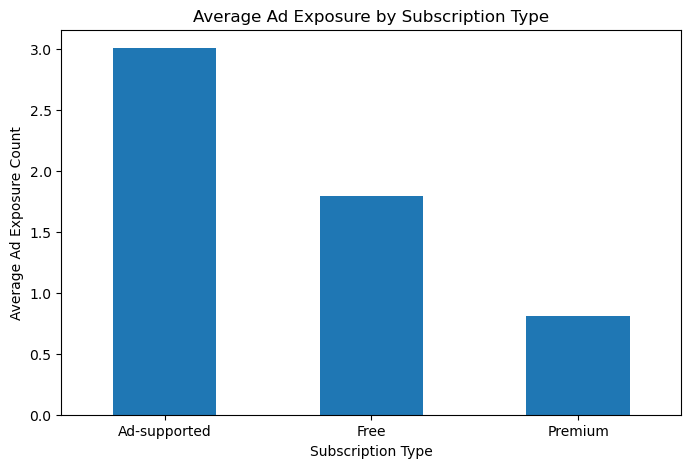

In [17]:
# Gender wise and
import matplotlib.pyplot as plt

avg_exposure = (
    raw_df.groupby('subscription_type')['ad_exposure_count']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
avg_exposure.plot(kind='bar')
plt.title("Average Ad Exposure by Subscription Type")
plt.ylabel("Average Ad Exposure Count")
plt.xlabel("Subscription Type")
plt.xticks(rotation=0)
plt.show()


**Interpretation:**  
Ad-supported users receive higher average ad exposure compared to premium
users. This aligns with expected platform monetization strategies and
confirms subscription type as a key driver of exposure.

<Figure size 800x500 with 0 Axes>

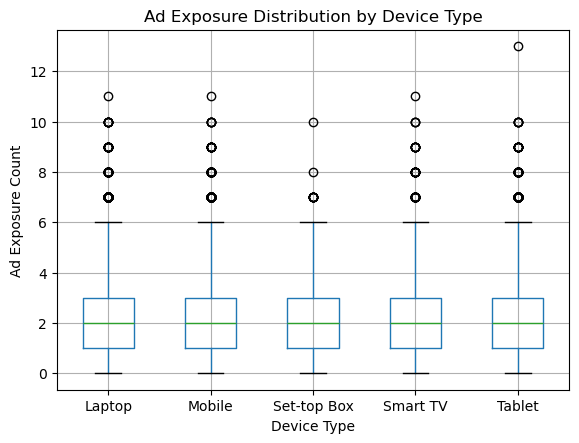

In [18]:
plt.figure(figsize=(8,5))
raw_df.boxplot(
    column='ad_exposure_count',
    by='device_type'
)
plt.title("Ad Exposure Distribution by Device Type")
plt.suptitle("")  # removes default subtitle
plt.ylabel("Ad Exposure Count")
plt.xlabel("Device Type")
plt.show()

**Interpretation:**  
Ad exposure differs across devices, suggesting that content consumption
patterns and session behavior vary by device. This emphasizes the importance
of device-level segmentation in media planning.

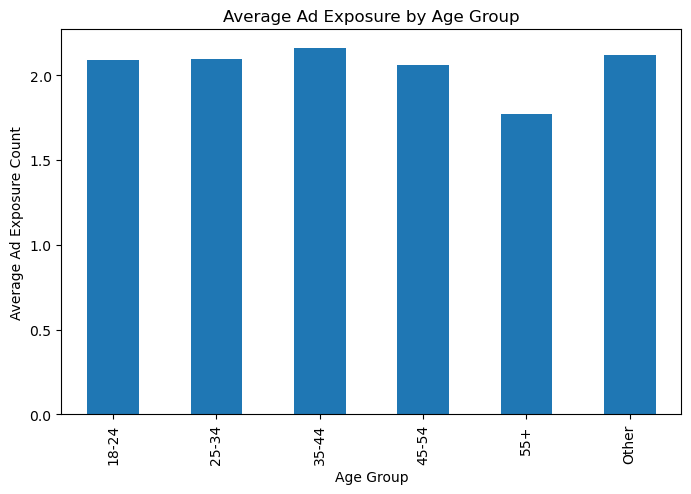

In [19]:
# Gender wise and
age_exposure = (
   raw_df.groupby('age_group')['ad_exposure_count']
      .mean()
)

plt.figure(figsize=(8,5))
age_exposure.plot(kind='bar')
plt.title("Average Ad Exposure by Age Group")
plt.ylabel("Average Ad Exposure Count")
plt.xlabel("Age Group")
plt.show()

**Interpretation:**  
Exposure levels vary across age groups, indicating that demographic factors
influence how users interact with content and ads. This supports the need
for audience-specific exposure strategies.

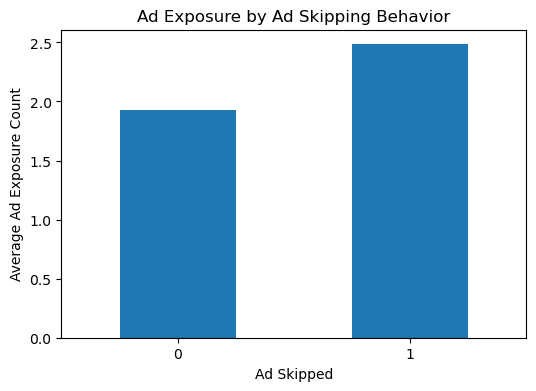

In [20]:
skip_exposure = (
    raw_df.groupby('ad_skipped')['ad_exposure_count']
      .mean()
)

plt.figure(figsize=(6,4))
skip_exposure.plot(kind='bar')
plt.title("Ad Exposure by Ad Skipping Behavior")
plt.ylabel("Average Ad Exposure Count")
plt.xlabel("Ad Skipped")
plt.xticks(rotation=0)
plt.show()

**Interpretation:**  
Users who frequently skip ads tend to have lower ad exposure. This suggests
that the platform may adjust ad delivery based on user behavior to manage
user experience and reduce ad fatigue.

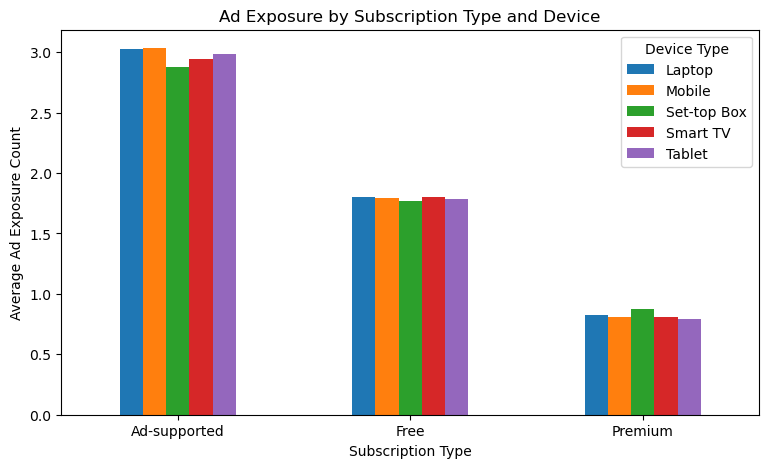

In [21]:
pivot_df = (
    raw_df.groupby(['subscription_type', 'device_type'])['ad_exposure_count']
      .mean()
      .unstack()
)

pivot_df.plot(kind='bar', figsize=(9,5))
plt.title("Ad Exposure by Subscription Type and Device")
plt.ylabel("Average Ad Exposure Count")
plt.xlabel("Subscription Type")
plt.xticks(rotation=0)
plt.legend(title="Device Type")
plt.show()

**Interpretation:**  
The combined view across multiple segments reveals interaction effects
between audience characteristics. This shows that ad exposure is shaped
by multiple factors together rather than a single variable in isolation.

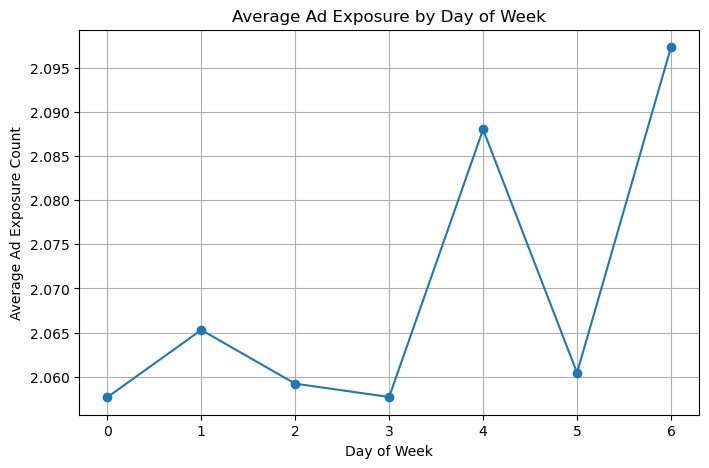

In [22]:
time_exposure = (
    raw_df.groupby('weekday_num')['ad_exposure_count']
      .mean()
)

plt.figure(figsize=(8,5))
time_exposure.plot(kind='line', marker='o')
plt.title("Average Ad Exposure by Day of Week")
plt.ylabel("Average Ad Exposure Count")
plt.xlabel("Day of Week")
plt.grid(True)
plt.show()

## Key EDA Insights (In Simple Words)

- From the analysis, it’s clear that ad exposure mainly depends on how users
consume content. Users who spend more time on the platform naturally see more
ads because there are more chances to show them.

- Subscription type plays a big role. Users on ad-supported plans receive
significantly more ads compared to premium users, which matches how streaming
platforms usually operate.

- We also see differences across devices and age groups. This suggests that user
behavior changes based on how and where content is consumed, so looking at
audience segments gives better insight than just overall averages.

- Users who frequently skip ads tend to receive fewer ads over time. This
indicates that the platform likely adjusts ad delivery based on user behavior
to avoid a poor viewing experience.

- Overall, ad exposure is not evenly distributed. A small group of users is
exposed to many ads, which highlights the need to manage ad frequency and avoid
over-exposure. These insights help set the foundation for using count-based
models to better understand and predict ad exposure.

### Inferential Analysis
- Testing association between target variable and discrete(categorical) features
- Using **Chi-squre** test 

In [23]:
from scipy.stats import chi2_contingency

print("Test results for the each pair of feature with target variable")
df = raw_df

for i in cat_cols:
    contingency_table = pd.crosstab(df['ad_exposure_count'], df[i])
    # print(contingency_table)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"\n{i} :")
    print("Chi-square statistic:", chi2)
    print("p-value:", p)
    print("Degrees of freedom:", dof,"\n")

Test results for the each pair of feature with target variable

age_group :
Chi-square statistic: 480.1250661504107
p-value: 7.597461373992024e-67
Degrees of freedom: 60 


gender :
Chi-square statistic: 15.47569372069092
p-value: 0.9060652802243592
Degrees of freedom: 24 


device_type :
Chi-square statistic: 134.27511882839832
p-value: 4.2424154417504805e-10
Degrees of freedom: 48 


os :
Chi-square statistic: 47.776002736382715
p-value: 0.48195905478375983
Degrees of freedom: 48 


content_type :
Chi-square statistic: 32.69958060675091
p-value: 0.9551823120763725
Degrees of freedom: 48 


content_genre :
Chi-square statistic: 44.22802760470108
p-value: 0.995937599688765
Degrees of freedom: 72 


subscription_type :
Chi-square statistic: 14175.32738706755
p-value: 0.0
Degrees of freedom: 24 


network_type :
Chi-square statistic: 29.53638170191763
p-value: 0.768187697593373
Degrees of freedom: 36 


timestamp :
Chi-square statistic: 548610.440458101
p-value: 0.0006996101465963334
Deg

## Interpretation of Chi-Square Test Results

The Chi-Square test results indicate a statistically significant association
between ad exposure and several categorical variables such as subscription
type, device type, age group, and ad skipping behavior.

This suggests that ad exposure is not randomly distributed across users and
is meaningfully related to audience characteristics and interaction signals.
These findings support the inclusion of these variables in predictive and
explanatory models for ad exposure.

Since the p-value is below the significance threshold, we reject the null
hypothesis and conclude that the variables are associated with ad exposure.

In [24]:
associated_features = ['watch_duration_minutes','ad_skipped','subscription_type','device_type','age_group','time_category','hour','weekday_num','month_num']
target = 'ad_exposure_count'

### Encoding the data 
- Numerical feature: Normalising 
- categorical : OHE/ Label E
- Using the column_trasformers and pipeline 

In [25]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define associated features and target
associated_features = ['subscription_type', 'device_type', 'age_group','time_category','watch_duration_minutes', 'hour','month_num','weekday_num']
target = 'ad_exposure_count'  # replace with your actual target column

X = raw_df[associated_features]
y = raw_df[target]

# Separate categorical and numerical features
categorical_features = ['subscription_type', 'device_type', 'age_group','time_category']
numerical_features = ['watch_duration_minutes', 'hour','month_num','weekday_num']

# One-hot encode categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(X[categorical_features])
cat_feature_names = encoder.get_feature_names_out(categorical_features)

# Scale numerical features
scaler = StandardScaler()
X_num = scaler.fit_transform(X[numerical_features])

# Combine encoded categorical + scaled numerical
import numpy as np
X_encoded = np.hstack([X_cat, X_num])

# Create new DataFrame with encoded features
encoded_df = pd.DataFrame(X_encoded, columns=list(cat_feature_names) + numerical_features)

# Add target back if needed
encoded_df[target] = y.values



In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_classification(y_test, y_pred):
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
    


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_regression(y_test, y_pred):

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Mean Absolute Percentage Error (optional, careful with zeros in y_test)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    print("Mean Absolute Error (MAE):", mae)
    print("Mean Squared Error (MSE):", mse)
    print("Root Mean Squared Error (RMSE):", rmse)
    print("R² Score:", r2)
    print("Mean Absolute Percentage Error (MAPE):", mape)


### Train Test Split
- spliting data for encoding and traing with ration of 80-20

In [28]:
from sklearn.model_selection import train_test_split
X = encoded_df.drop(columns=target)
y= encoded_df[target]

# splitng the data 
X_train, X_test, y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=3)


## Regression approach 

In [29]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

evaluate_regression(y_test, y_pred)

Mean Absolute Error (MAE): 1.0916944225465328
Mean Squared Error (MSE): 2.0005918402247977
Root Mean Squared Error (RMSE): 1.4144227940134442
R² Score: 0.23939314464032158
Mean Absolute Percentage Error (MAPE): inf


In [30]:
## RandomForest 

from sklearn.ensemble import RandomForestRegressor

model_rfr = RandomForestRegressor()

model_rfr.fit(X_train, y_train)

y_pred = model_rfr.predict(X_test)

evaluate_regression(y_test, y_pred)

Mean Absolute Error (MAE): 1.1426470166666667
Mean Squared Error (MSE): 2.1443238355138887
Root Mean Squared Error (RMSE): 1.4643509946436641
R² Score: 0.18474754489663603
Mean Absolute Percentage Error (MAPE): inf


In [31]:
# poisson
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
X_val_sm   = sm.add_constant(X_test)

poisson_model = sm.GLM(
    y_train,
    X_train_sm,
    family=sm.families.Poisson()
).fit()

y_val_pred_poisson = poisson_model.predict(X_val_sm)

evaluate_regression(y_test, y_val_pred_poisson)

Mean Absolute Error (MAE): 1.0926156035934007
Mean Squared Error (MSE): 2.0010895033450042
Root Mean Squared Error (RMSE): 1.4145987075298083
R² Score: 0.23920393764003411
Mean Absolute Percentage Error (MAPE): inf


### Performances of Models

| Model                | MAE  | MSE  | RMSE | R² Score |
|----------------------|------|------|------|----------|
| Linear Regression    | 1.09 | 2.00 | 1.41 | 0.24     |
| Random F Regression  | 1.14 | 2.15 | 1.47 | 0.18     |
| Poisson Regression   | 1.09 | 2.0  | 1.41 | 0.23     |

**Note on evaluation metrics:**  
The dependent variable *ad_exposure_count* is inherently noisy and driven by 
many unobserved factors. As a result, R² is not a reliable measure of model 
quality in this context. Mean Absolute Error (MAE) and Root Mean Squared Error 
(RMSE) provide more meaningful insight into prediction performance.

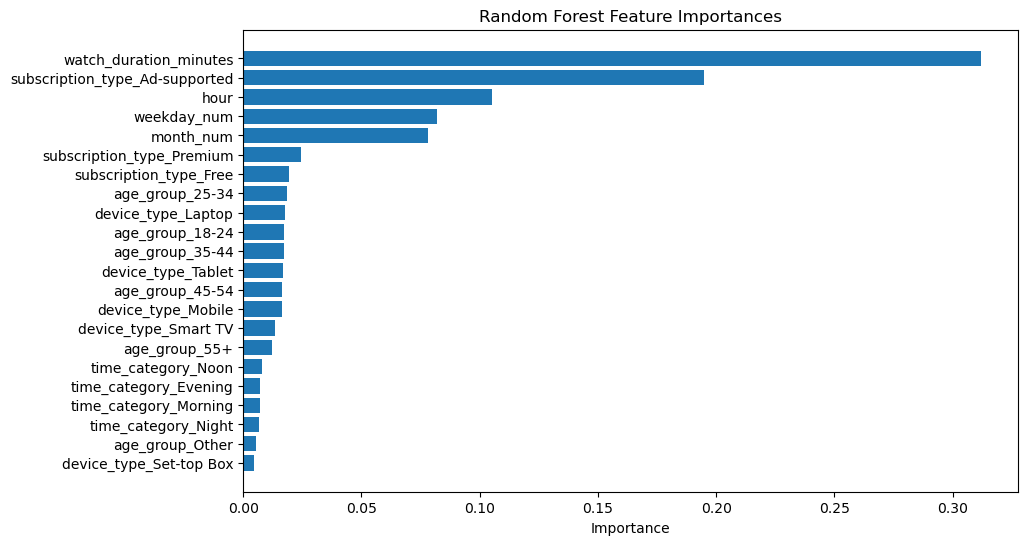

In [32]:

# Get feature importances
importances = model_rfr.feature_importances_

# Match with feature names (after encoding)
feature_names = encoded_df.drop(columns=[target]).columns  # assuming encoded_df includes target

# Create DataFrame for easy sorting
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_importances['Feature'], feat_importances['Importance'])
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.show()


### Key Drivers of Ad Exposure

- Watch duration is the strongest driver of ad exposure, indicating that
  longer content consumption leads to higher ad delivery.
- Subscription type significantly impacts exposure, with ad-supported users
  receiving higher exposure.
- Device type and age group show meaningful variation, highlighting
  audience-level differences in ad delivery.

## Classification approach 
- Treating the target variable as 5 different categories :  0 - 3 indivisual and last one as 4+(which will be written as 4 only)
- For that transforming the ad_exposure_count

In [33]:
def transform_target(x):
    if x>=4:
        return 4
    else:
        return x
encoded_df['ad_exposure_count'] = encoded_df['ad_exposure_count'].apply(transform_target)

In [34]:
X = encoded_df.drop(columns=target)
y= encoded_df[target]

# splitng the data 
X_train, X_test, y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=3)

In [35]:
#### Logistic Regression 
from sklearn.linear_model import LogisticRegression

model_lr  =LogisticRegression()

#model fiting 
model_lr.fit(X_train, y_train)

# model prediction 
y_pred = model_lr.predict(X_test)

#evaluation 
evaluate_classification(y_test, y_pred)

Accuracy: 0.3437
Precision: 0.2897508860882759
Recall: 0.3437
F1 Score: 0.26529520134538936


In [36]:
### Decision tree 
from sklearn.tree import DecisionTreeClassifier

model_dtc = DecisionTreeClassifier()

model_dtc.fit(X_train, y_train)

y_pred = model_dtc.predict(X_test)

evaluate_classification(y_test, y_pred)

Accuracy: 0.2573
Precision: 0.25760621647086057
Recall: 0.2573
F1 Score: 0.2574316818802653


In [37]:
### Random forest 
from sklearn.ensemble import RandomForestClassifier

model_rfc = RandomForestClassifier()

model_rfc.fit(X_train, y_train)

y_pred = model_rfc.predict(X_test)

evaluate_classification(y_test, y_pred)

Accuracy: 0.2754
Precision: 0.2710300887354741
Recall: 0.2754
F1 Score: 0.27205576335419335


## Segment-Level Insights

- Ad exposure is higher among ad-supported subscription users compared to
  premium users.
- Younger age groups exhibit slightly higher exposure, potentially due to
  higher session frequency.
- Mobile and tablet users show marginally higher exposure than laptop users.

## Business Recommendations

1. Optimize ad frequency by focusing on high watch-duration sessions while
   avoiding over-exposure that may lead to ad fatigue.
2. Allocate more ad inventory to ad-supported subscription tiers where
   exposure potential is higher.
3. Customize media strategies by device type and age group to improve
   exposure efficiency.